# Controlling the machine tool interactively

This notebook can be used to controlling the machine tool interactively.

Forst, we have to setup some paths for Python to load the necessary MADS class:

In [1]:
import time
import sys, os
import subprocess
mads_path = subprocess.check_output(["mads", "-p"], text=True).strip()
sys.path.append(os.path.join(mads_path, 'python'))

Now we can create an Agent and use it to publish (or receive) messages:

In [2]:
from mads_agent import Agent, EventType, MessageType, mads_version, mads_default_settings_uri

Loading MADS lib from default /Users/paolorossi/usr/local/lib/libMadsCore.dylib


We create an agent with the name `python`: this will be the settings section being loaded:

In [3]:
ag = Agent("python")
ag.init()
ag.connect()

0

As per the `mads.ini` file, section `[python]`, this agent publishes on `machine_tool_control`.

Now we can publish JSON objects to control the FMU simulator (listening on `machine_tool_control` and publishing on `fmu_machine_tool`) or the Rerun viewer (listening on `fmu_machine_tool`):

In [4]:
ag.publish({"fmu_input": {"setpoint": [0, 0, 100]}}, "machine_tool_control")

0

In [5]:
ag.publish({"fmu_input": {"setpoint": [1000, 1000, 1000]}}, "machine_tool_control")

0

If we need to publish on a different topic, we pass it as a second argument:

In [6]:
ag.publish({"tool": {"length": 100, "diameter": 20, "z_offset": 50}}, "fmu_machine_tool")

0

In [7]:
ag.publish({"reset": True})

0

# PID tuning

Here we are starting an infinite loop to set a square wave with a period of 10 seconds

**This is an infinite loop**

In [8]:
# while True:
#   try:
#     ag.publish({"fmu_input": {"setpoint": [0, 0, 0]}})
#     time.sleep(5)
#     ag.publish({"fmu_input": {"setpoint": [100, 0, 0]}})
#     time.sleep(5)
#   except KeyboardInterrupt:
#     break
ag.publish({"fmu_input": {"setpoint": [0, 0, 0]}})
ag.publish({"reset": True})

0

In [9]:
ag.publish({"fmu_input": {"setpoint": [0, 0, 0]}}, "machine_tool_control")

0

# Maximum acceleration estimation

Here we will need to receive messages from the machine.
We **need** to be subscribed to the topic `fmu_machine_tool` to receive the output from the FMU. Make sure that in the file mads.ini in the section python there is the line: `sub_topic = ["fmu_machine_tool"]`. 

We first receive the message with `ag.receive()`, then we get the actual data with `ag.last_message()`

In [10]:
ag.receive()
topic, data = ag.last_message()

In [11]:
data

{'agent_id': '',
 'hostname': 'prossi-macair.local',
 'timecode': 55464.12,
 'timestamp': {'$date': '2026-05-26T15:24:24.129+0200'},
 'tool': {'diameter': 20, 'length': 100, 'z_offset': 50}}

In [12]:
# here we are getting the speed from the machine
if "output" in data.keys():
    data["output"]["speed"][0]

To plot and to 

To install matplotlib, first you have to activate the same venv of the jupyter notebook, then you can run: `pip install matplotlib`

In [13]:
%pip install matplotlib
%pip install numpy

import matplotlib.pyplot as plt
import numpy as np

  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 1.2 MB/s  0:00:07 eta 0:00:010:01:020m
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 2.5 MB/s  0:00:01m 2.3 MB/s eta 0:00:01
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl (64 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib] 5/6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [14]:
# Asking the machine to go to the origin
ag.publish({"fmu_input": {"setpoint": [0, 0, 0]}})
ag.disconnect()
# Waiting for the machine to reach the position [0,0,0]
time.sleep(1.0)
ag.connect()
# setting back a large queue to get all the interesting messages
ag.set_queue_size(100)
time.sleep(0.1) # wait a bit for connecting
# Setting a new position to then compute the machine acceleration
ag.publish({"fmu_input": {"setpoint": [1000, 1000, 1000]}})

prev_speed = 0
prev_time = 0

time_history = []
setpoint_history = []
position_history = []
speed_history = []
acceleration_history = []

for i in range(300): # same as (in c++): for(int i = 0; i < 300; i++){}
  ag.receive()
  topic, data = ag.last_message()
  if not topic == "fmu_machine_tool" or not "input" in data.keys() or not "output" in data.keys():
    continue
  t = data["timecode"]

  setpoint = np.array(data["input"]["setpoint"]) / 1e3
  position = np.array(data["output"]["position"]) / 1e3
  speed = np.array(data["output"]["speed"]) / 1e3

  if (t - prev_time == 0):
    continue

  acceleration = (speed - prev_speed) / (t - prev_time)
  prev_speed = speed
  prev_time = t

  time_history.append(t)
  setpoint_history.append(setpoint)
  position_history.append(position)
  speed_history.append(speed)
  acceleration_history.append(acceleration)

time_history = np.array(time_history) - time_history[0]
maximum_acceleration = np.max(np.abs(acceleration_history))
minimum_acceleration = np.min(np.max(np.abs(acceleration_history), axis=0))
print(f"Maximum acceleration: {maximum_acceleration} m/s^2")
print(f"Minimum acceleration: {minimum_acceleration} m/s^2")

Maximum acceleration: 345.0556705717987 m/s^2
Minimum acceleration: 345.05557968188737 m/s^2


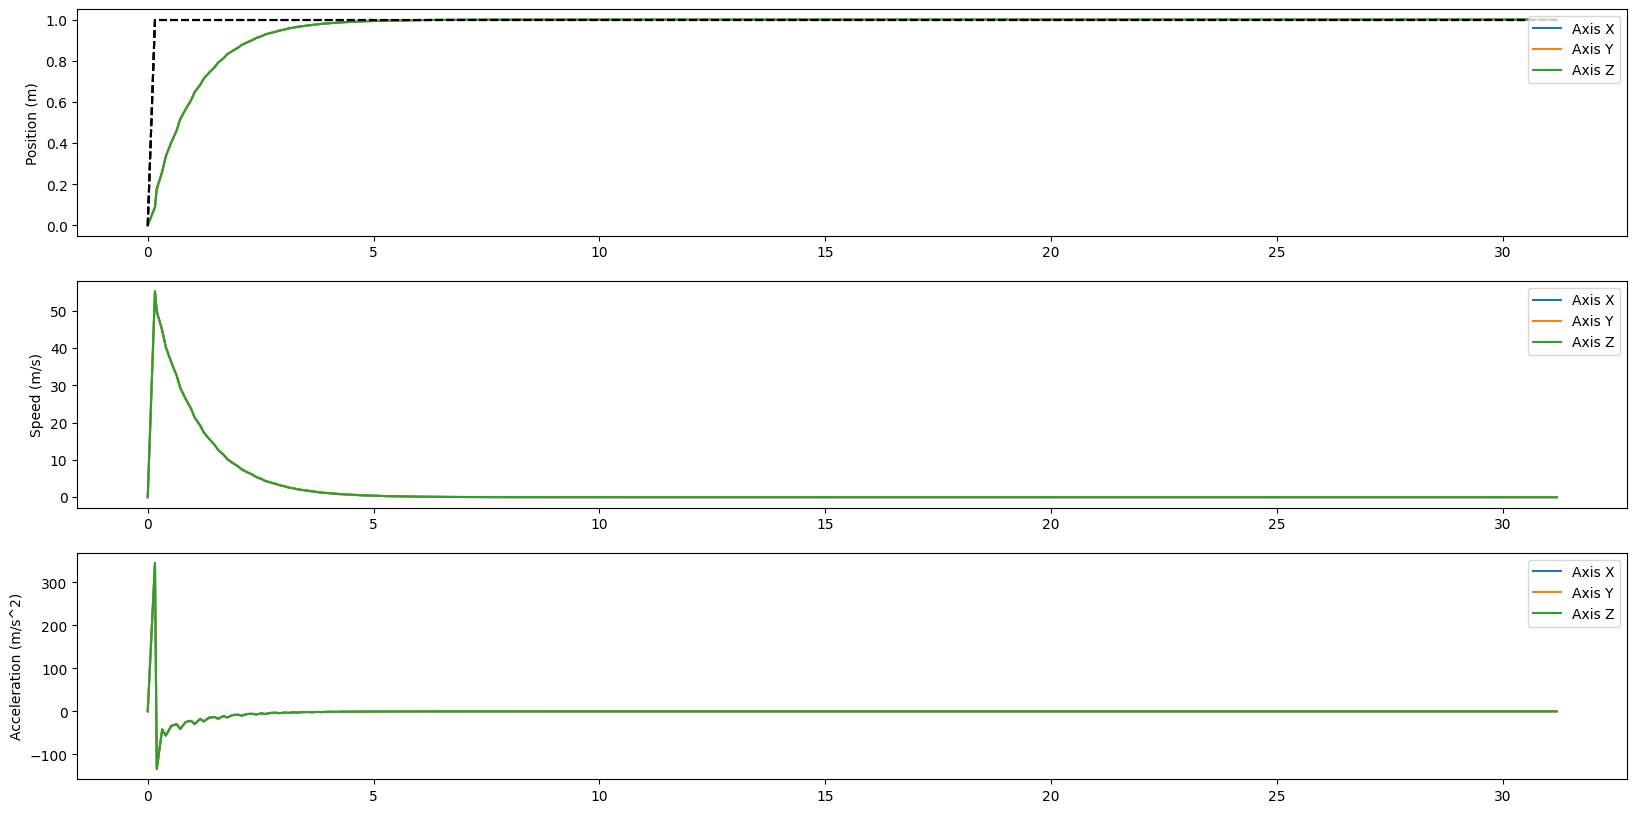

In [15]:
plt.figure(figsize=(20, 10))
plt.subplot(3, 1, 1)
plt.plot(time_history, position_history, label="position (m)")
plt.plot(time_history, setpoint_history, '--k')
plt.legend(["Axis X", "Axis Y", "Axis Z"], loc="upper right")
plt.ylabel("Position (m)")
plt.subplot(3, 1, 2)
plt.plot(time_history, speed_history, label= "speed (m/s)")
plt.legend(["Axis X", "Axis Y", "Axis Z"], loc="upper right")
plt.ylabel("Speed (m/s)")
plt.subplot(3, 1, 3)
plt.plot(time_history, acceleration_history, label="acceleration (m/s^2)")
plt.legend(["Axis X", "Axis Y", "Axis Z"], loc="upper right")
_ = plt.ylabel("Acceleration (m/s^2)")
